# CEASA Price Forecast


## 1. Contexto do problema

O Mercado do Produtor de Juazeiro é um importante centro de comercialização de hortifrutigranjeiros no Vale do São Francisco. Diariamente, produtores, comerciantes e compradores precisam tomar decisões relacionadas à compra, venda, estoque e negociação de produtos agrícolas.

No entanto, os preços desses produtos podem variar ao longo do tempo por fatores como oferta, demanda, sazonalidade, clima, disponibilidade de produtos e dinâmica do mercado atacadista. Essa variação dificulta o planejamento dos agentes envolvidos na cadeia produtiva.

Diante desse cenário, a análise de dados pode ser utilizada para organizar informações públicas de cotações, identificar padrões de comportamento dos preços e construir modelos capazes de apoiar a previsão do preço médio de determinados produtos comercializados no Mercado do Produtor de Juazeiro.

## 2. Objetivo

O objetivo deste projeto é coletar, tratar, analisar e modelar dados públicos de cotações de produtos hortifrutigranjeiros comercializados no Mercado do Produtor de Juazeiro.

A proposta é desenvolver uma solução baseada em dados capaz de:

- organizar as cotações em uma base estruturada;
- analisar o comportamento dos preços ao longo do tempo;
- identificar produtos com maior variação de preço;
- construir modelos estatísticos ou de machine learning para prever o preço médio dos produtos;
- apresentar visualizações que auxiliem na interpretação dos resultados.

A variável alvo do projeto será o preço médio do produto, representado pela coluna `avg_price`.

## 3. Fontes de dados

A fonte de dados utilizada neste projeto é pública e não confidencial.

Os dados foram coletados a partir da página da Autarquia Municipal de Abastecimento (AMA), vinculada à Prefeitura de Juazeiro. A AMA divulga cotações atualizadas dos hortifrutigranjeiros comercializados no Mercado do Produtor de Juazeiro.

A escolha dessa fonte se justifica por sua relação direta com o problema analisado, já que as publicações tratam especificamente dos preços praticados no mercado atacadista local.

Fonte utilizada:

- Autarquia Municipal de Abastecimento (AMA) — Prefeitura de Juazeiro

## 4. Importação das bibliotecas

In [1]:
# Importação das bibliotecas
import os
import re
import unicodedata
import requests
import pandas as pd

from bs4 import BeautifulSoup
from urllib.parse import urljoin
from tqdm import tqdm

# Importação das bibliotecas principais
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import warnings
warnings.filterwarnings("ignore")

## 5. Coleta dos dados

A coleta dos dados foi realizada por meio de extração web na página da Autarquia Municipal de Abastecimento (AMA), no portal da Prefeitura de Juazeiro.

O processo de coleta consistiu em:

1. acessar as páginas de notícias da categoria AMA;
2. identificar publicações relacionadas às cotações de hortifrutigranjeiros;
3. coletar o link, título e data de cada publicação;
4. acessar cada notícia individualmente;
5. extrair o texto da publicação;
6. identificar produtos e preços mencionados no conteúdo textual;
7. organizar os registros em uma base tabular para análise.

Como as publicações nem sempre apresentam a tabela completa no corpo da notícia, esta etapa inicial utiliza os produtos e preços destacados nas matérias. Essa abordagem permite construir uma primeira base pública e reprodutível para análise exploratória e modelagem.


In [2]:
# Configurações iniciais

BASE_URL = "https://www.juazeiro.ba.gov.br"
AMA_URL = "https://www.juazeiro.ba.gov.br/category/autarquia-municipal-de-abastecimento-ama/"

headers = {
    "User-Agent": "Mozilla/5.0"
}


def normalize_text(text):
    """
    Remove acentos, converte para minúsculas e elimina espaços extras.
    """
    text = str(text)
    text = unicodedata.normalize("NFKD", text)
    text = text.encode("ascii", "ignore").decode("utf-8")
    return text.lower().strip()


def get_soup(url):
    """
    Acessa uma página web e retorna o HTML tratado pelo BeautifulSoup.
    """
    response = requests.get(url, headers=headers, timeout=20)
    response.raise_for_status()
    response.encoding = "utf-8"
    return BeautifulSoup(response.text, "html.parser")

In [3]:
def get_ama_article_links(n_pages=30):
    """
    Coleta os links das publicações da AMA relacionadas às cotações.
    """
    article_links = []

    for page in range(1, n_pages + 1):
        if page == 1:
            url = AMA_URL
        else:
            url = f"{AMA_URL}page/{page}/"

        try:
            soup = get_soup(url)
        except Exception as e:
            print(f"Erro ao acessar página {page}: {e}")
            continue

        links = soup.find_all("a", href=True)

        for link in links:
            title = link.get_text(" ", strip=True)
            href = urljoin(BASE_URL, link["href"])

            title_norm = normalize_text(title)
            href_norm = normalize_text(href)

            is_cotacao = (
                "cotacao" in title_norm
                or "cotacao" in href_norm
                or "precos atualizados" in title_norm
                or "precos-atualizados" in href_norm
            )

            is_mercado_produtor = (
                "mercado do produtor" in title_norm
                or "mercado-do-produtor" in href_norm
                or "hortifrutigranjeiros" in title_norm
                or "hortifrutigranjeiros" in href_norm
            )

            if is_cotacao and is_mercado_produtor:
                article_links.append({
                    "title": title,
                    "url": href
                })

    df_links = pd.DataFrame(article_links)
    df_links = df_links.drop_duplicates(subset="url").reset_index(drop=True)

    return df_links


df_ama_links = get_ama_article_links(n_pages=30)

df_ama_links.head()

,title,url
0,Autarquia municipal de abastecimento - ama AMA...,https://www.juazeiro.ba.gov.br/ama-divulga-cot...
1,Autarquia municipal de abastecimento - ama AMA...,https://www.juazeiro.ba.gov.br/ama-divulga-cot...
2,Autarquia municipal de abastecimento - ama AMA...,https://www.juazeiro.ba.gov.br/ama-divulga-cot...
3,Autarquia municipal de abastecimento - ama AMA...,https://www.juazeiro.ba.gov.br/ama-divulga-cot...
4,Autarquia municipal de abastecimento - ama Pre...,https://www.juazeiro.ba.gov.br/prefeitura-divu...


In [4]:
# Quantidade de notícias de cotação encontradas

df_ama_links.shape

(164, 2)

In [5]:
def extract_article_data(url):
    """
    Extrai título, data, texto e possíveis links internos de uma notícia.
    """
    try:
        soup = get_soup(url)
    except Exception as e:
        return {
            "url": url,
            "title": None,
            "date": None,
            "text": None,
            "related_links": [],
            "error": str(e)
        }

    title_tag = soup.find("h1")
    title = title_tag.get_text(" ", strip=True) if title_tag else None

    text = soup.get_text(" ", strip=True)

    date_match = re.search(r"\d{2}/\d{2}/\d{4}", text)
    date = date_match.group(0) if date_match else None

    related_links = []

    for a in soup.find_all("a", href=True):
        link_text = normalize_text(a.get_text(" ", strip=True))
        href = urljoin(BASE_URL, a["href"])

        if "aqui" in link_text or "cotacao" in normalize_text(href):
            related_links.append(href)

    related_links = list(set(related_links))

    return {
        "url": url,
        "title": title,
        "date": date,
        "text": text,
        "related_links": related_links,
        "error": None
    }

In [6]:
# Extração dos dados das notícias

articles_data = []

for url in tqdm(df_ama_links["url"]):
    data = extract_article_data(url)
    articles_data.append(data)

df_ama_articles = pd.DataFrame(articles_data)

df_ama_articles.head()

100%|████████████████████████████████████████| 164/164 [03:21<00:00,  1.23s/it]


,url,title,date,text,related_links,error
0,https://www.juazeiro.ba.gov.br/ama-divulga-cot...,AMA divulga cotação dos hortifrutigranjeiros c...,11/06/2026,AMA divulga cotação dos hortifrutigranjeiros c...,[https://api.whatsapp.com/send?text=www.juazei...,None
1,https://www.juazeiro.ba.gov.br/ama-divulga-cot...,AMA divulga cotação dos hortifrutigranjeiros c...,10/06/2026,AMA divulga cotação dos hortifrutigranjeiros c...,[https://www.juazeiro.ba.gov.br/ama-divulga-co...,None
2,https://www.juazeiro.ba.gov.br/ama-divulga-cot...,AMA divulga cotação dos hortifrutigranjeiros c...,01/06/2026,AMA divulga cotação dos hortifrutigranjeiros c...,[https://www.juazeiro.ba.gov.br/wp-content/upl...,None
3,https://www.juazeiro.ba.gov.br/ama-divulga-cot...,AMA divulga cotação dos hortifrutigranjeiros c...,28/05/2026,AMA divulga cotação dos hortifrutigranjeiros c...,[https://www.linkedin.com/shareArticle?url=www...,None
4,https://www.juazeiro.ba.gov.br/prefeitura-divu...,Prefeitura divulga preços atualizados de horti...,14/05/2026,Prefeitura divulga preços atualizados de horti...,[https://www.juazeiro.ba.gov.br/forro-raiz-tra...,None


In [7]:
# Salvando a base bruta de notícias

os.makedirs("data/raw", exist_ok=True)

df_ama_links.to_csv("data/raw/ama_article_links.csv", index=False)
df_ama_articles.to_csv("data/raw/ama_articles_raw.csv", index=False)

print("Bases brutas salvas com sucesso.")

Bases brutas salvas com sucesso.


In [8]:
def convert_price_to_float(price):
    """
    Converte preço em formato brasileiro ou decimal para float.
    Remove pontos finais, espaços e outros caracteres indesejados.
    """
    price = str(price).strip()

    # Captura apenas o primeiro padrão numérico encontrado
    match = re.search(r"\d+(?:[,.]\d{1,2})?", price)

    if match is None:
        return None

    price = match.group(0)
    price = price.replace(",", ".")

    return float(price)


def extract_prices_from_text(row):
    """
    Extrai produtos, unidades e preços citados no texto das notícias.
    """
    text = row["text"]
    date = row["date"]
    source_url = row["url"]

    if pd.isna(text):
        return []

    records = []

    # Quebra o texto em sentenças para facilitar a extração
    sentences = re.split(r"(?<=[.!?])\s+", text)

    for sentence in sentences:
        if "R$" not in sentence:
            continue

        sentence_clean = " ".join(sentence.split())

        patterns = [
            # Exemplo: A caixa de mamão formosa, com 20 quilos, está sendo comercializada por R$ 22,50
            r"(?:o|a|O|A|já o|já a|enquanto o|enquanto a)\s+(saco|caixa|quilo|cento)\s+(?:de|do|da)\s+(.+?)(?:,\s*com\s*(.+?))?\s+(?:está|esta|é|e|pode|custa|sai).*?R\$\s*([\d.,]+)",

            # Exemplo: a laranja está sendo vendida a R$ 22,50 o cento
            r"(?:o|a|O|A|já o|já a|enquanto o|enquanto a)\s+(.+?)\s+(?:está sendo vendida|está sendo vendido|custa|sai por|é comercializada|é comercializado).*?R\$\s*([\d.,]+)\s+(?:o|a)\s+([^.;,]+)"
        ]

        for idx, pattern in enumerate(patterns):
            matches = re.findall(pattern, sentence_clean, flags=re.IGNORECASE)

            for match in matches:
                if idx == 0:
                    unit_type = match[0].strip()
                    product_name = match[1].strip()
                    unit_detail = match[2].strip() if match[2] else ""
                    price = match[3]

                    unit = f"{unit_type} {unit_detail}".strip()

                else:
                    product_name = match[0].strip()
                    price = match[1]
                    unit = match[2].strip()

                records.append({
                    "date": date,
                    "product_name": product_name,
                    "unit": unit,
                    "avg_price": convert_price_to_float(price),
                    "source": "AMA",
                    "source_url": source_url,
                    "market": "Mercado do Produtor de Juazeiro",
                    "city": "Juazeiro",
                    "state": "BA"
                })

    return records

In [9]:
# Aplicando a extração de preços

all_price_records = []

for _, row in df_ama_articles.iterrows():
    records = extract_prices_from_text(row)
    all_price_records.extend(records)

df_ama_prices = pd.DataFrame(all_price_records)

df_ama_prices.head()

,date,product_name,unit,avg_price,source,source_url,market,city,state
0,11/06/2026,milho,cento,37.50,AMA,https://www.juazeiro.ba.gov.br/ama-divulga-cot...,Mercado do Produtor de Juazeiro,Juazeiro,BA
1,10/06/2026,feijão de corda,"saco 60 quilos,",240.00,AMA,https://www.juazeiro.ba.gov.br/ama-divulga-cot...,Mercado do Produtor de Juazeiro,Juazeiro,BA
2,10/06/2026,"milho, também com 60 quilos,",saco,100.00,AMA,https://www.juazeiro.ba.gov.br/ama-divulga-cot...,Mercado do Produtor de Juazeiro,Juazeiro,BA
3,10/06/2026,feijão preto,quilo,6.67,AMA,https://www.juazeiro.ba.gov.br/ama-divulga-cot...,Mercado do Produtor de Juazeiro,Juazeiro,BA
4,01/06/2026,cenoura,"saco 20 quilos,",150.00,AMA,https://www.juazeiro.ba.gov.br/ama-divulga-cot...,Mercado do Produtor de Juazeiro,Juazeiro,BA


In [10]:
# Quantidade de preços extraídos

df_ama_prices.shape

(126, 9)

In [11]:
# Tratamento inicial da base extraída

if not df_ama_prices.empty:
    df_ama_prices["date"] = pd.to_datetime(df_ama_prices["date"], format="%d/%m/%Y", errors="coerce")
    df_ama_prices["product_name"] = df_ama_prices["product_name"].str.strip().str.lower()
    df_ama_prices["unit"] = df_ama_prices["unit"].str.strip().str.lower()

    df_ama_prices = df_ama_prices.drop_duplicates()
    df_ama_prices = df_ama_prices.sort_values(["product_name", "date"]).reset_index(drop=True)

df_ama_prices.head()

,date,product_name,unit,avg_price,source,source_url,market,city,state
0,2025-04-11,20 quilos,saco,50.00,AMA,https://www.juazeiro.ba.gov.br/confira-a-cotac...,Mercado do Produtor de Juazeiro,Juazeiro,BA
1,2025-05-30,26kg,caixa,80.00,AMA,https://www.juazeiro.ba.gov.br/confira-a-cotac...,Mercado do Produtor de Juazeiro,Juazeiro,BA
2,2025-03-06,27 quilos,caixa,280.00,AMA,https://www.juazeiro.ba.gov.br/confira-a-cotac...,Mercado do Produtor de Juazeiro,Juazeiro,BA
3,2026-04-28,abacate,quilo,3.25,AMA,https://www.juazeiro.ba.gov.br/ama-divulga-pre...,Mercado do Produtor de Juazeiro,Juazeiro,BA
4,2024-11-19,"abacate a r$ 23,00, a caixa com 14 kg de couve...",quilo,8.00,AMA,https://www.juazeiro.ba.gov.br/confira-a-cotac...,Mercado do Produtor de Juazeiro,Juazeiro,BA


In [12]:
# Salvando a base processada

os.makedirs("data/processed", exist_ok=True)

df_ama_prices.to_csv("data/processed/ama_prices_processed.csv", index=False)

print("Base processada salva com sucesso.")

Base processada salva com sucesso.


## 6. Tratamento e preparação

Após a extração dos dados, foi necessário realizar uma etapa de limpeza para melhorar a qualidade da base.

Como os dados foram coletados diretamente do texto das notícias da AMA, alguns registros apresentaram ruídos, principalmente na coluna `product_name`. Em determinados casos, a expressão regular capturou unidades de comercialização, pesos ou trechos longos da frase no lugar do nome do produto.

Dessa forma, foram aplicadas as seguintes etapas de tratamento:

- conversão da data para o formato datetime;
- padronização dos nomes dos produtos;
- padronização das unidades de comercialização;
- remoção de registros duplicados;
- remoção de registros com nomes inválidos;
- remoção de trechos que continham preços ou pesos no campo de produto;
- organização da base final para análise exploratória.

Essa etapa é importante porque a qualidade dos dados influencia diretamente a análise e a modelagem.

In [13]:
# Cópia da base extraída
df_clean = df_ama_prices.copy()

df_clean.head()

,date,product_name,unit,avg_price,source,source_url,market,city,state
0,2025-04-11,20 quilos,saco,50.00,AMA,https://www.juazeiro.ba.gov.br/confira-a-cotac...,Mercado do Produtor de Juazeiro,Juazeiro,BA
1,2025-05-30,26kg,caixa,80.00,AMA,https://www.juazeiro.ba.gov.br/confira-a-cotac...,Mercado do Produtor de Juazeiro,Juazeiro,BA
2,2025-03-06,27 quilos,caixa,280.00,AMA,https://www.juazeiro.ba.gov.br/confira-a-cotac...,Mercado do Produtor de Juazeiro,Juazeiro,BA
3,2026-04-28,abacate,quilo,3.25,AMA,https://www.juazeiro.ba.gov.br/ama-divulga-pre...,Mercado do Produtor de Juazeiro,Juazeiro,BA
4,2024-11-19,"abacate a r$ 23,00, a caixa com 14 kg de couve...",quilo,8.00,AMA,https://www.juazeiro.ba.gov.br/confira-a-cotac...,Mercado do Produtor de Juazeiro,Juazeiro,BA


In [14]:
def clean_product_name(name):
    """
    Padroniza e limpa o nome dos produtos extraídos do texto.
    """
    if pd.isna(name):
        return None
    
    name = str(name).lower().strip()
    
    # Remove quebras de linha e espaços duplicados
    name = " ".join(name.split())
    
    # Remove trechos depois de vírgulas quando vierem explicações longas
    name = name.split(",")[0].strip()
    
    # Remove trechos com preço
    name = re.sub(r"a\s*r\$\s*[\d,.]+.*", "", name)
    name = re.sub(r"por\s*r\$\s*[\d,.]+.*", "", name)
    name = re.sub(r"r\$\s*[\d,.]+.*", "", name)
    
    # Remove expressões introdutórias
    name = re.sub(r"^(o|a|os|as|já o|já a|enquanto o|enquanto a)\s+", "", name)
    
    # Remove unidade no início, caso tenha sido capturada junto
    name = re.sub(r"^(saco|caixa|quilo|cento)\s+(de|do|da)\s+", "", name)
    
    # Remove espaços novamente
    name = " ".join(name.split()).strip()
    
    return name

In [15]:
df_clean["product_name"] = df_clean["product_name"].apply(clean_product_name)

df_clean.head()

,date,product_name,unit,avg_price,source,source_url,market,city,state
0,2025-04-11,20 quilos,saco,50.00,AMA,https://www.juazeiro.ba.gov.br/confira-a-cotac...,Mercado do Produtor de Juazeiro,Juazeiro,BA
1,2025-05-30,26kg,caixa,80.00,AMA,https://www.juazeiro.ba.gov.br/confira-a-cotac...,Mercado do Produtor de Juazeiro,Juazeiro,BA
2,2025-03-06,27 quilos,caixa,280.00,AMA,https://www.juazeiro.ba.gov.br/confira-a-cotac...,Mercado do Produtor de Juazeiro,Juazeiro,BA
3,2026-04-28,abacate,quilo,3.25,AMA,https://www.juazeiro.ba.gov.br/ama-divulga-pre...,Mercado do Produtor de Juazeiro,Juazeiro,BA
4,2024-11-19,abacate,quilo,8.00,AMA,https://www.juazeiro.ba.gov.br/confira-a-cotac...,Mercado do Produtor de Juazeiro,Juazeiro,BA


In [16]:
# Padrões que indicam que o nome do produto foi capturado incorretamente
invalid_patterns = [
    r"^\d+$",
    r"^\d+\s*kg$",
    r"^\d+\s*kgs$",
    r"^\d+\s*quilos?$",
    r"^\d+\s*quilo$",
    r"kg",
    r"quilo",
    r"quilos",
    r"r\$",
    r"caixa com",
    r"saco com",
    r"segunda-feira",
    r"terça-feira",
    r"quarta-feira",
    r"quinta-feira",
    r"sexta-feira",
    r"sábado",
    r"domingo",
    r"feira"
]

pattern = "|".join(invalid_patterns)

df_clean = df_clean[
    ~df_clean["product_name"].str.contains(pattern, regex=True, na=False)
].copy()

df_clean.head()

,date,product_name,unit,avg_price,source,source_url,market,city,state
3,2026-04-28,abacate,quilo,3.25,AMA,https://www.juazeiro.ba.gov.br/ama-divulga-pre...,Mercado do Produtor de Juazeiro,Juazeiro,BA
4,2024-11-19,abacate,quilo,8.00,AMA,https://www.juazeiro.ba.gov.br/confira-a-cotac...,Mercado do Produtor de Juazeiro,Juazeiro,BA
5,2025-01-09,abacate,quilo,150.00,AMA,https://www.juazeiro.ba.gov.br/confira-a-cotac...,Mercado do Produtor de Juazeiro,Juazeiro,BA
6,2025-01-06,abacate,quilo,60.00,AMA,https://www.juazeiro.ba.gov.br/confira-a-cotac...,Mercado do Produtor de Juazeiro,Juazeiro,BA
7,2025-04-30,abacate,quilo,90.00,AMA,https://www.juazeiro.ba.gov.br/confira-a-cotac...,Mercado do Produtor de Juazeiro,Juazeiro,BA


In [17]:
def clean_unit(unit):
    """
    Padroniza a unidade de comercialização.
    """
    if pd.isna(unit):
        return None
    
    unit = str(unit).lower().strip()
    unit = " ".join(unit.split())
    unit = unit.replace(",", "").replace(".", "")
    
    return unit


df_clean["unit"] = df_clean["unit"].apply(clean_unit)

df_clean.head()

,date,product_name,unit,avg_price,source,source_url,market,city,state
3,2026-04-28,abacate,quilo,3.25,AMA,https://www.juazeiro.ba.gov.br/ama-divulga-pre...,Mercado do Produtor de Juazeiro,Juazeiro,BA
4,2024-11-19,abacate,quilo,8.00,AMA,https://www.juazeiro.ba.gov.br/confira-a-cotac...,Mercado do Produtor de Juazeiro,Juazeiro,BA
5,2025-01-09,abacate,quilo,150.00,AMA,https://www.juazeiro.ba.gov.br/confira-a-cotac...,Mercado do Produtor de Juazeiro,Juazeiro,BA
6,2025-01-06,abacate,quilo,60.00,AMA,https://www.juazeiro.ba.gov.br/confira-a-cotac...,Mercado do Produtor de Juazeiro,Juazeiro,BA
7,2025-04-30,abacate,quilo,90.00,AMA,https://www.juazeiro.ba.gov.br/confira-a-cotac...,Mercado do Produtor de Juazeiro,Juazeiro,BA


In [18]:
# Conversão da data
df_clean["date"] = pd.to_datetime(
    df_clean["date"], 
    errors="coerce"
)

# Remoção de registros sem data, produto ou preço

df_clean = df_clean.dropna(
    subset=["date", "product_name", "avg_price"]
)

# Remoção de duplicados

df_clean = df_clean.drop_duplicates(
    subset=["date", "product_name", "unit", "avg_price"]
)

# Ordenação da base

df_clean = df_clean.sort_values(
    ["product_name", "date"]
).reset_index(drop=True)

df_clean.head()

,date,product_name,unit,avg_price,source,source_url,market,city,state
0,2024-11-19,abacate,quilo,8.0,AMA,https://www.juazeiro.ba.gov.br/confira-a-cotac...,Mercado do Produtor de Juazeiro,Juazeiro,BA
1,2025-01-06,abacate,quilo,60.0,AMA,https://www.juazeiro.ba.gov.br/confira-a-cotac...,Mercado do Produtor de Juazeiro,Juazeiro,BA
2,2025-01-09,abacate,quilo,150.0,AMA,https://www.juazeiro.ba.gov.br/confira-a-cotac...,Mercado do Produtor de Juazeiro,Juazeiro,BA
3,2025-01-28,abacate,quilo,70.0,AMA,https://www.juazeiro.ba.gov.br/confira-a-cotac...,Mercado do Produtor de Juazeiro,Juazeiro,BA
4,2025-04-08,abacate,quilo,90.0,AMA,https://www.juazeiro.ba.gov.br/confira-a-cotac...,Mercado do Produtor de Juazeiro,Juazeiro,BA


In [19]:
df_clean.shape

(104, 9)

In [20]:
df_clean["product_name"].value_counts().head(20)

product_name
melancia            9
abacate             8
jerimum             5
castanha de caju    4
manjericão          4
morango             4
cenoura             3
abacaxi             2
abóbora comum       2
alecrim             2
açafrão             2
batata-doce         2
batatinha           2
caju                2
chuchu              2
chá verde           2
coco verde          2
jaca                2
laranja             2
linhaça             2
Name: count, dtype: int64

Após a limpeza, a base foi reduzida em relação ao total inicial de registros extraídos. Essa redução ocorreu porque alguns registros apresentavam nomes de produtos inválidos, geralmente causados pela estrutura textual das notícias.

A decisão de remover esses registros foi tomada para preservar a qualidade da análise e evitar que informações incorretas influenciassem os resultados da modelagem.

In [21]:
df_clean.shape
df_clean["product_name"].value_counts().head(20)
df_clean.head()

,date,product_name,unit,avg_price,source,source_url,market,city,state
0,2024-11-19,abacate,quilo,8.0,AMA,https://www.juazeiro.ba.gov.br/confira-a-cotac...,Mercado do Produtor de Juazeiro,Juazeiro,BA
1,2025-01-06,abacate,quilo,60.0,AMA,https://www.juazeiro.ba.gov.br/confira-a-cotac...,Mercado do Produtor de Juazeiro,Juazeiro,BA
2,2025-01-09,abacate,quilo,150.0,AMA,https://www.juazeiro.ba.gov.br/confira-a-cotac...,Mercado do Produtor de Juazeiro,Juazeiro,BA
3,2025-01-28,abacate,quilo,70.0,AMA,https://www.juazeiro.ba.gov.br/confira-a-cotac...,Mercado do Produtor de Juazeiro,Juazeiro,BA
4,2025-04-08,abacate,quilo,90.0,AMA,https://www.juazeiro.ba.gov.br/confira-a-cotac...,Mercado do Produtor de Juazeiro,Juazeiro,BA


In [22]:
# Padronização final da unidade de comercialização

def simplify_unit(unit):
    """
    Simplifica a unidade para categorias principais.
    """
    unit = str(unit).lower()

    if "quilo" in unit or "kg" in unit:
        return "quilo"
    elif "caixa" in unit:
        return "caixa"
    elif "saco" in unit:
        return "saco"
    elif "cento" in unit:
        return "cento"
    else:
        return "outros"


df_clean["unit_simple"] = df_clean["unit"].apply(simplify_unit)

df_clean[["product_name", "unit", "unit_simple", "avg_price"]].head()

,product_name,unit,unit_simple,avg_price
0,abacate,quilo,quilo,8.0
1,abacate,quilo,quilo,60.0
2,abacate,quilo,quilo,150.0
3,abacate,quilo,quilo,70.0
4,abacate,quilo,quilo,90.0


In [23]:
# Salvando a base limpa
df_clean.to_csv(
    "data/processed/ama_prices_clean.csv", 
    index=False
)

print("Base limpa salva com sucesso.")

Base limpa salva com sucesso.


## 7. Análise exploratória

Nesta etapa, foi realizada uma análise exploratória da base limpa com o objetivo de compreender a estrutura dos dados coletados, o período disponível, a quantidade de produtos, a distribuição dos preços e os produtos com maior frequência nas publicações.

Como os dados foram extraídos diretamente do texto das notícias, a base apresenta limitações em relação ao volume e à padronização. Mesmo assim, ela permite observar padrões iniciais de comportamento dos preços divulgados pela AMA.

### 7.1 Visão geral da base

In [24]:
# Verificando a quantidade de linhas e colunas na base limpa
df_clean.shape

(104, 10)

In [25]:
# Verificando os tipos de dados
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          104 non-null    datetime64[us]
 1   product_name  104 non-null    str           
 2   unit          104 non-null    str           
 3   avg_price     104 non-null    float64       
 4   source        104 non-null    str           
 5   source_url    104 non-null    str           
 6   market        104 non-null    str           
 7   city          104 non-null    str           
 8   state         104 non-null    str           
 9   unit_simple   104 non-null    str           
dtypes: datetime64[us](1), float64(1), str(8)
memory usage: 8.3 KB


In [26]:
# Verificando estatísticas descritivas dos preços
df_clean["avg_price"].describe()

count    104.000000
mean     110.587596
std       94.998233
min        1.200000
25%       48.750000
50%       90.000000
75%      150.000000
max      500.000000
Name: avg_price, dtype: float64

In [27]:
# Verificando o período analisado
periodo_inicio = df_clean["date"].min()
periodo_fim = df_clean["date"].max()

print(f"Período da base: {periodo_inicio.date()} até {periodo_fim.date()}")
print(f"Quantidade de produtos únicos: {df_clean['product_name'].nunique()}")
print(f"Quantidade de registros: {len(df_clean)}")

Período da base: 2024-06-20 até 2026-06-11
Quantidade de produtos únicos: 56
Quantidade de registros: 104


### 7.2 Produtos com mais registros

In [28]:
# Verificando os produtos com maior quantidade de registros
top_products = df_clean["product_name"].value_counts().head(15)

top_products

product_name
melancia            9
abacate             8
jerimum             5
castanha de caju    4
manjericão          4
morango             4
cenoura             3
abacaxi             2
abóbora comum       2
alecrim             2
açafrão             2
batata-doce         2
batatinha           2
caju                2
chuchu              2
Name: count, dtype: int64

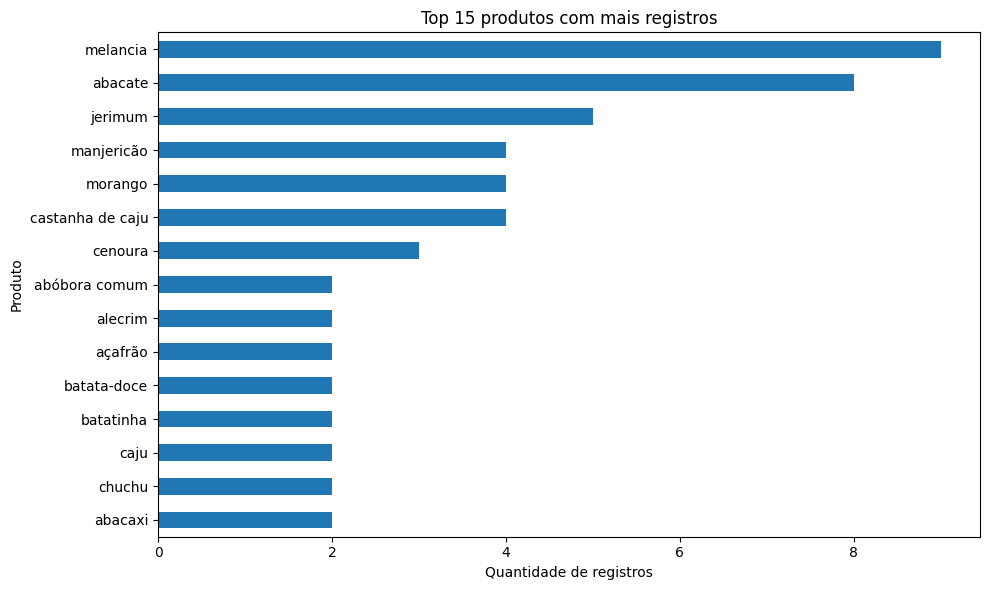

In [29]:
plt.figure(figsize=(10, 6))
top_products.sort_values().plot(kind="barh")

plt.title("Top 15 produtos com mais registros")
plt.xlabel("Quantidade de registros")
plt.ylabel("Produto")
plt.tight_layout()
plt.show()

Os produtos com maior quantidade de registros são os que aparecem com mais frequência nas notícias coletadas. Esses produtos são mais adequados para análises de comportamento ao longo do tempo, pois possuem maior histórico disponível.

### 7.3 Distribuição dos preços

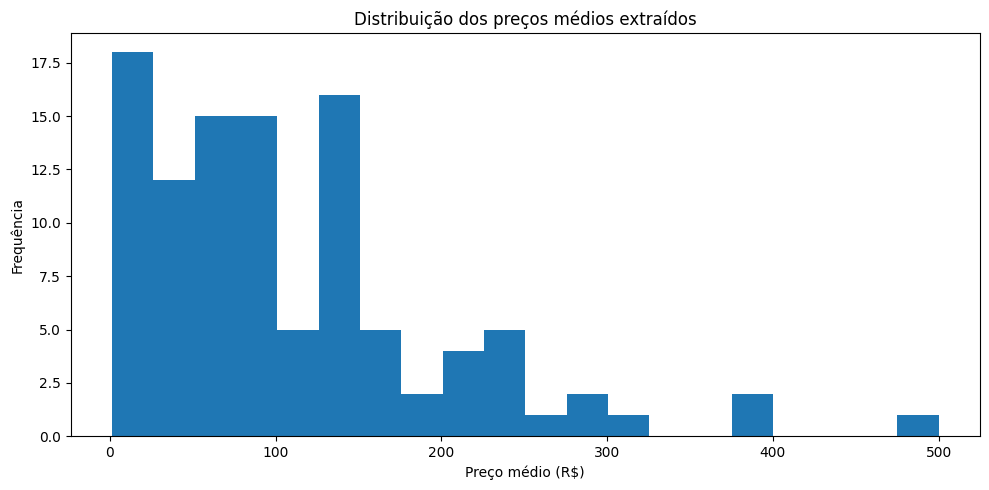

In [30]:
plt.figure(figsize=(10, 5))
plt.hist(df_clean["avg_price"], bins=20)

plt.title("Distribuição dos preços médios extraídos")
plt.xlabel("Preço médio (R$)")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

A distribuição dos preços mostra a presença de produtos com valores bastante diferentes, o que é esperado em uma base de hortifrutigranjeiros, já que os produtos possuem unidades de comercialização distintas, como quilo, caixa, saco e cento.

### 7.4 Preço médio por produto

In [31]:
# Top 10 produtos com maior preço médio
avg_price_by_product = (
    df_clean
    .groupby("product_name")["avg_price"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

avg_price_by_product

product_name
canela              400.0
pimenta do reino    320.0
ameixa seca         300.0
alho                290.0
ovos                270.0
abacaxi             255.0
feijão de corda     240.0
castanha de caju    212.5
açafrão             190.0
manjericão          185.0
Name: avg_price, dtype: float64

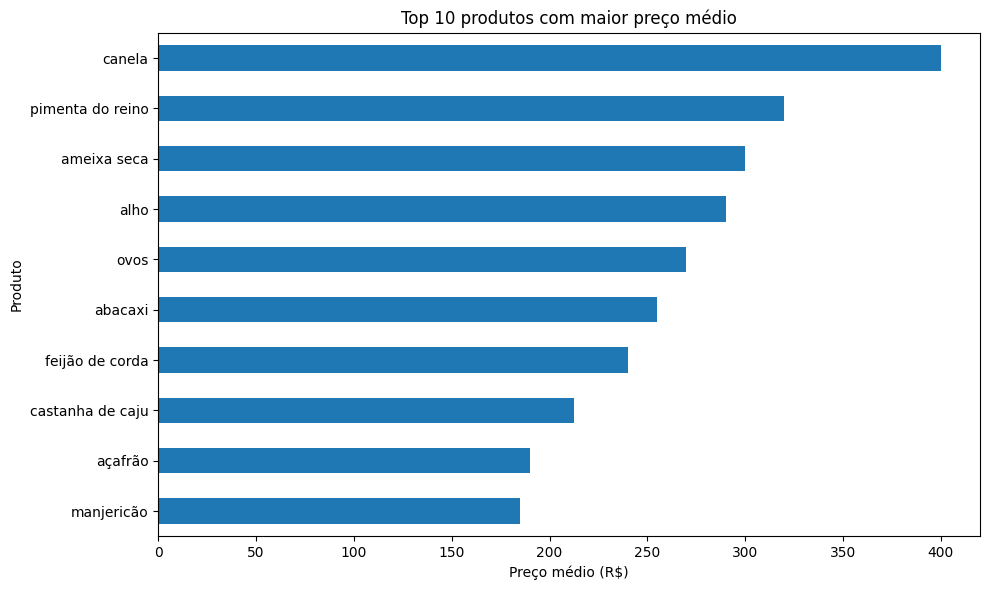

In [32]:
plt.figure(figsize=(10, 6))
avg_price_by_product.sort_values().plot(kind="barh")

plt.title("Top 10 produtos com maior preço médio")
plt.xlabel("Preço médio (R$)")
plt.ylabel("Produto")
plt.tight_layout()
plt.show()

Os produtos com maior preço médio devem ser interpretados com cautela, pois a base contém diferentes unidades de comercialização, como quilo, caixa, saco e cento. Portanto, o preço médio não representa uma comparação direta entre produtos, mas sim o valor médio registrado conforme a unidade informada nas notícias.

### 7.5 Variação de preços por produto

In [33]:
# Produtos com pelo menos 2 registros para cálculo de variação
price_variation = (
    df_clean
    .groupby("product_name")
    .agg(
        registros=("avg_price", "count"),
        preco_minimo=("avg_price", "min"),
        preco_medio=("avg_price", "mean"),
        preco_maximo=("avg_price", "max"),
        desvio_padrao=("avg_price", "std")
    )
    .reset_index()
)

price_variation = price_variation[price_variation["registros"] >= 2]

price_variation.sort_values("desvio_padrao", ascending=False).head(10)

,product_name,registros,preco_minimo,preco_medio,preco_maximo,desvio_padrao
18,castanha de caju,4,40.00,212.500000,500.0,213.756092
1,abacaxi,2,110.00,255.000000,400.0,205.060967
32,jaca,2,1.20,125.600000,250.0,175.928167
44,melão amarelo,2,50.00,145.000000,240.0,134.350288
11,batata-doce,2,1.55,67.025000,132.5,92.595633
21,cenoura,3,5.00,101.666667,150.0,83.715789
43,melancia,9,1.20,115.133333,220.0,82.291616
12,batatinha,2,50.00,100.000000,150.0,70.710678
0,abacate,8,3.25,81.406250,180.0,61.712169
36,linhaça,2,30.00,70.000000,110.0,56.568542


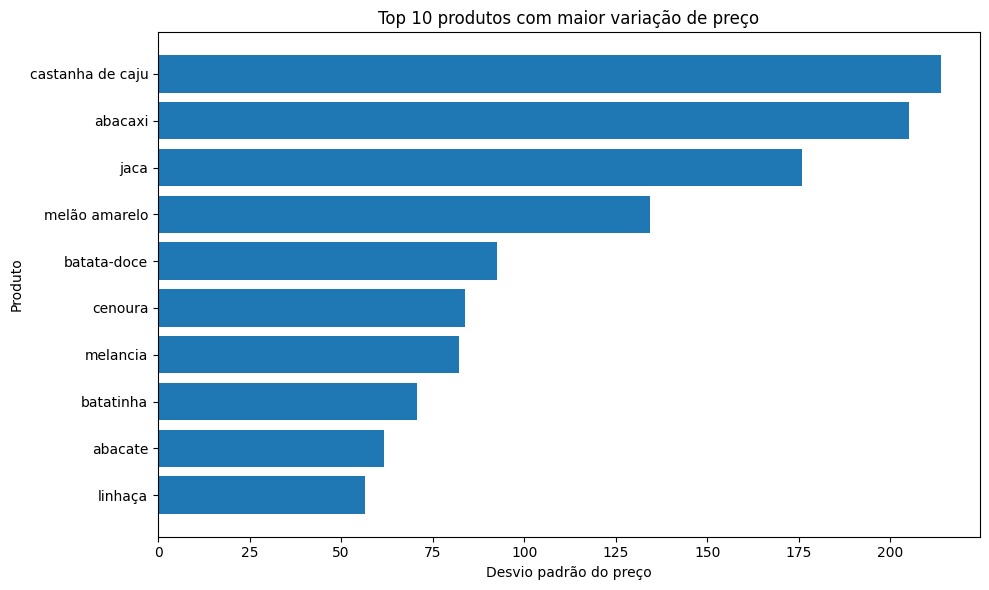

In [34]:
top_variation = (
    price_variation
    .sort_values("desvio_padrao", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.barh(top_variation["product_name"], top_variation["desvio_padrao"])

plt.title("Top 10 produtos com maior variação de preço")
plt.xlabel("Desvio padrão do preço")
plt.ylabel("Produto")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

A análise de variação permite identificar produtos com maior oscilação de preço ao longo das publicações coletadas. Esses produtos podem ser mais sensíveis a fatores como oferta, demanda, sazonalidade e disponibilidade no mercado.

### 7.6 Evolução temporal dos produtos mais frequentes

In [35]:
# Seleção dos produtos com mais registros
selected_products = df_clean["product_name"].value_counts().head(5).index

df_selected = df_clean[df_clean["product_name"].isin(selected_products)].copy()

df_selected.head()

,date,product_name,unit,avg_price,source,source_url,market,city,state,unit_simple
0,2024-11-19,abacate,quilo,8.0,AMA,https://www.juazeiro.ba.gov.br/confira-a-cotac...,Mercado do Produtor de Juazeiro,Juazeiro,BA,quilo
1,2025-01-06,abacate,quilo,60.0,AMA,https://www.juazeiro.ba.gov.br/confira-a-cotac...,Mercado do Produtor de Juazeiro,Juazeiro,BA,quilo
2,2025-01-09,abacate,quilo,150.0,AMA,https://www.juazeiro.ba.gov.br/confira-a-cotac...,Mercado do Produtor de Juazeiro,Juazeiro,BA,quilo
3,2025-01-28,abacate,quilo,70.0,AMA,https://www.juazeiro.ba.gov.br/confira-a-cotac...,Mercado do Produtor de Juazeiro,Juazeiro,BA,quilo
4,2025-04-08,abacate,quilo,90.0,AMA,https://www.juazeiro.ba.gov.br/confira-a-cotac...,Mercado do Produtor de Juazeiro,Juazeiro,BA,quilo


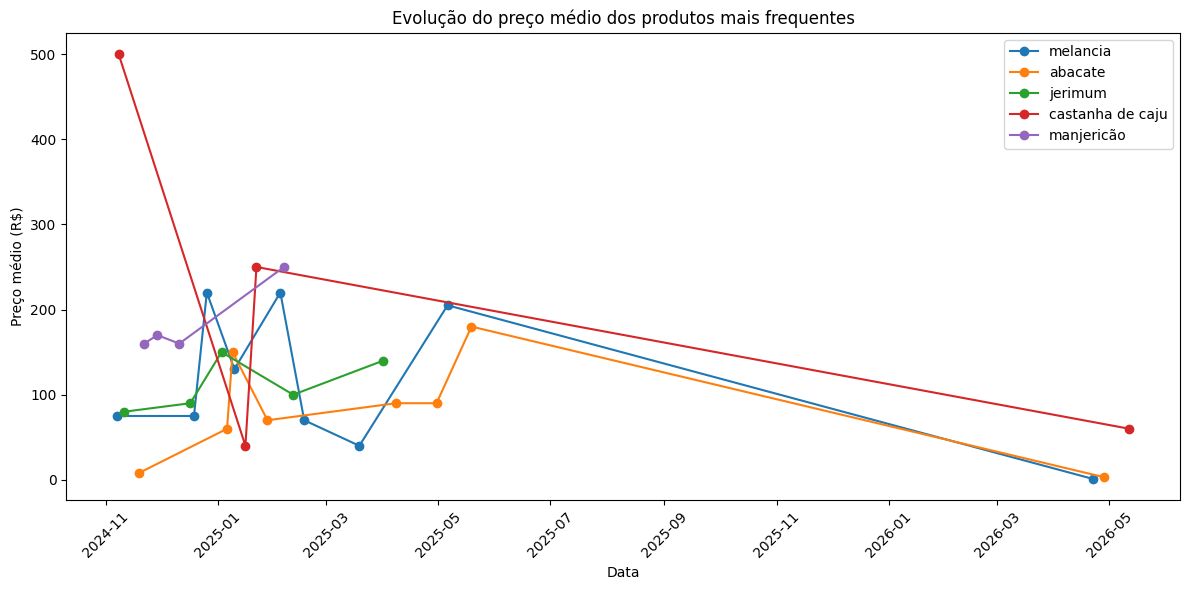

In [36]:
plt.figure(figsize=(12, 6))

for product in selected_products:
    data_product = df_selected[df_selected["product_name"] == product]
    data_product = data_product.sort_values("date")
    plt.plot(data_product["date"], data_product["avg_price"], marker="o", label=product)

plt.title("Evolução do preço médio dos produtos mais frequentes")
plt.xlabel("Data")
plt.ylabel("Preço médio (R$)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

A evolução temporal mostra que alguns produtos apresentam oscilações relevantes entre as datas coletadas. No entanto, como a base foi construída a partir dos produtos destacados nas notícias e não da tabela completa de cotações, o histórico ainda é limitado para alguns itens.

### 7.7 Verificação das unidades

In [37]:
# Unidades de comercialização simplificadas
df_clean["unit_simple"].value_counts()

unit_simple
quilo    93
cento     7
saco      2
caixa     2
Name: count, dtype: int64

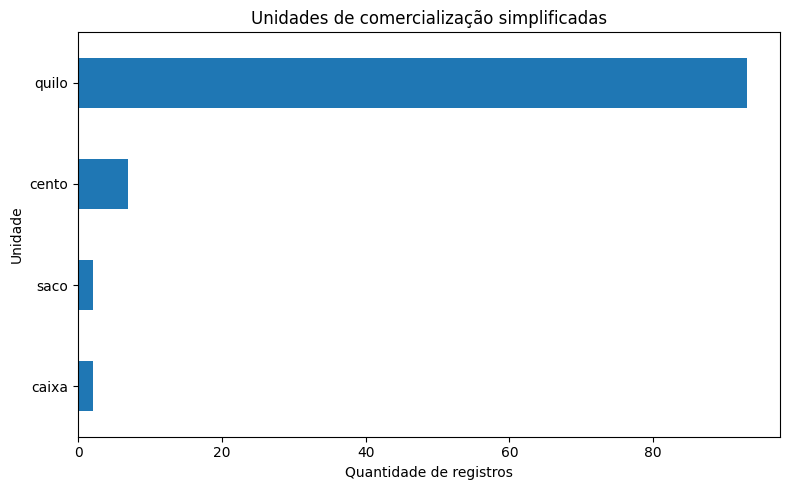

In [38]:
unit_counts = df_clean["unit_simple"].value_counts()

plt.figure(figsize=(8, 5))
unit_counts.sort_values().plot(kind="barh")

plt.title("Unidades de comercialização simplificadas")
plt.xlabel("Quantidade de registros")
plt.ylabel("Unidade")
plt.tight_layout()
plt.show()

A análise exploratória mostrou que a base coletada possui registros de diferentes produtos hortifrutigranjeiros comercializados no Mercado do Produtor de Juazeiro. Os produtos com maior frequência na base foram utilizados como referência para avaliar o comportamento dos preços ao longo do tempo.

A diferença entre as unidades de comercialização influencia diretamente a interpretação dos preços. Por esse motivo, a modelagem deve considerar variáveis como produto, unidade e data da cotação.

Apesar da limitação no volume de dados, a base permite construir um modelo inicial de previsão de preço médio, com caráter exploratório e educacional.

## 8. Modelagem

Nesta etapa, foram construídos modelos de regressão para prever o preço médio (`avg_price`) dos produtos a partir das informações disponíveis na base.

Como a base possui volume reduzido e foi extraída a partir dos textos das notícias da AMA, a modelagem tem caráter exploratório. O objetivo não é construir um modelo definitivo de previsão de preços, mas demonstrar como dados públicos podem ser organizados e utilizados em uma solução inicial baseada em machine learning.

Foram utilizadas como variáveis explicativas:

- nome do produto;
- unidade de comercialização simplificada;
- ano da cotação;
- mês da cotação;
- dia da semana.

A variável alvo foi o preço médio do produto.

In [39]:
# Criação da base para modelagem
df_model = df_clean.copy()

df_model["year"] = df_model["date"].dt.year
df_model["month"] = df_model["date"].dt.month
df_model["day_of_week"] = df_model["date"].dt.dayofweek

df_model.head()

,date,product_name,unit,avg_price,source,source_url,market,city,state,unit_simple,year,month,day_of_week
0,2024-11-19,abacate,quilo,8.0,AMA,https://www.juazeiro.ba.gov.br/confira-a-cotac...,Mercado do Produtor de Juazeiro,Juazeiro,BA,quilo,2024,11,1
1,2025-01-06,abacate,quilo,60.0,AMA,https://www.juazeiro.ba.gov.br/confira-a-cotac...,Mercado do Produtor de Juazeiro,Juazeiro,BA,quilo,2025,1,0
2,2025-01-09,abacate,quilo,150.0,AMA,https://www.juazeiro.ba.gov.br/confira-a-cotac...,Mercado do Produtor de Juazeiro,Juazeiro,BA,quilo,2025,1,3
3,2025-01-28,abacate,quilo,70.0,AMA,https://www.juazeiro.ba.gov.br/confira-a-cotac...,Mercado do Produtor de Juazeiro,Juazeiro,BA,quilo,2025,1,1
4,2025-04-08,abacate,quilo,90.0,AMA,https://www.juazeiro.ba.gov.br/confira-a-cotac...,Mercado do Produtor de Juazeiro,Juazeiro,BA,quilo,2025,4,1


In [40]:
# Seleção das variáveis explicativas e da variável alvo
features = ["product_name", "unit_simple", "year", "month", "day_of_week"]
target = "avg_price"

X = df_model[features]
y = df_model[target]

X.head()

,product_name,unit_simple,year,month,day_of_week
0,abacate,quilo,2024,11,1
1,abacate,quilo,2025,1,0
2,abacate,quilo,2025,1,3
3,abacate,quilo,2025,1,1
4,abacate,quilo,2025,4,1


In [41]:
# Codificação das variáveis categóricas
X_encoded = pd.get_dummies(
    X,
    columns=["product_name", "unit_simple"],
    drop_first=True
)

X_encoded.head()

,year,month,day_of_week,product_name_abacaxi,product_name_abóbora comum,product_name_abóbora jacarezinha,product_name_alecrim,product_name_alho,product_name_ameixa seca,product_name_anis,...,product_name_pimentão,product_name_pimentão de segunda linha manteve estabilidade,product_name_pinha,product_name_produto subiu,product_name_tomate de primeira linha,product_name_uva vitória,product_name_vagem,unit_simple_cento,unit_simple_quilo,unit_simple_saco
0,2024,11,1,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,2025,1,0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,2025,1,3,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,2025,1,1,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,2025,4,1,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False


In [42]:
# Separação entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.25,
    random_state=42
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (78, 61)
Teste: (26, 61)


In [43]:
# Modelo baseline: previsão pela média do conjunto de treino

baseline_pred = [y_train.mean()] * len(y_test)

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = mean_squared_error(y_test, baseline_pred) ** 0.5
baseline_r2 = r2_score(y_test, baseline_pred)

baseline_results = {
    "Modelo": "Baseline - média geral",
    "MAE": baseline_mae,
    "RMSE": baseline_rmse,
    "R2": baseline_r2
}

baseline_results

{'Modelo': 'Baseline - média geral',
 'MAE': 66.88338264299803,
 'RMSE': 91.76419828318066,
 'R2': -0.023889326263073052}

In [44]:
# Treinamento dos modelos de regressão

models = {
    "Regressão Linear": LinearRegression(),
    "Árvore de Decisão": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=100),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = [baseline_results]
predictions = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    predictions[model_name] = y_pred
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Modelo": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

df_results = pd.DataFrame(results)

df_results

,Modelo,MAE,RMSE,R2
0,Baseline - média geral,66.883383,91.764198,-0.023889
1,Regressão Linear,91.713582,122.591972,-0.827387
2,Árvore de Decisão,91.501923,122.815631,-0.834061
3,Random Forest,78.026375,110.925222,-0.496122
4,Gradient Boosting,76.317857,108.906564,-0.442164


As métricas utilizadas foram MAE, RMSE e R². O MAE indica o erro médio absoluto das previsões em reais, enquanto o RMSE penaliza erros maiores. O R² indica o quanto da variação do preço foi explicada pelo modelo.

Como a base possui poucos registros e diferentes unidades de comercialização, os resultados devem ser interpretados com cautela. Ainda assim, a modelagem permite avaliar se os algoritmos conseguem capturar padrões iniciais a partir das variáveis disponíveis.

## 9. Avaliação dos modelos

A avaliação dos modelos mostrou que o baseline baseado na média geral do conjunto de treino apresentou o menor erro entre as abordagens testadas.

O modelo Gradient Boosting foi o melhor entre os algoritmos de machine learning, porém não superou o baseline. Esse resultado indica que, para a base coletada, os modelos mais complexos ainda não conseguiram capturar padrões suficientes para melhorar a previsão.

Esse comportamento pode ser explicado por alguns fatores:

- volume reduzido de dados;
- muitos produtos com poucos registros históricos;
- diferentes unidades de comercialização;
- base construída a partir de textos de notícias, e não de uma tabela padronizada;
- alta quantidade de variáveis após o One-Hot Encoding em relação ao número de registros.

O R² negativo indica que os modelos tiveram desempenho inferior a uma previsão simples baseada na média. Portanto, os resultados devem ser interpretados como uma primeira versão exploratória da solução.

In [45]:
# Ordenando os modelos pelo menor MAE
df_results_sorted = df_results.sort_values("MAE").reset_index(drop=True)

df_results_sorted

,Modelo,MAE,RMSE,R2
0,Baseline - média geral,66.883383,91.764198,-0.023889
1,Gradient Boosting,76.317857,108.906564,-0.442164
2,Random Forest,78.026375,110.925222,-0.496122
3,Árvore de Decisão,91.501923,122.815631,-0.834061
4,Regressão Linear,91.713582,122.591972,-0.827387


In [46]:
# Identificação do melhor modelo geral
best_overall_model = df_results_sorted.iloc[0]

best_overall_model

Modelo    Baseline - média geral
MAE                    66.883383
RMSE                   91.764198
R2                     -0.023889
Name: 0, dtype: object

In [47]:
# Melhor modelo de machine learning, desconsiderando o baseline
df_ml_results = df_results[
    df_results["Modelo"] != "Baseline - média geral"
].copy()

best_ml_model = df_ml_results.sort_values("MAE").iloc[0]

best_ml_model

Modelo    Gradient Boosting
MAE               76.317857
RMSE             108.906564
R2                -0.442164
Name: 4, dtype: object

O melhor resultado geral foi obtido pelo baseline, indicando que a média geral ainda é uma referência forte para esta base. Entre os modelos de machine learning, o Gradient Boosting apresentou o menor MAE e RMSE.

Dessa forma, o projeto evidencia que a construção de uma base mais ampla e padronizada seria essencial para melhorar o desempenho preditivo em versões futuras.

## 10. Visualização dos resultados

Nesta etapa, foram criadas visualizações para comparar o desempenho dos modelos e observar a relação entre valores reais e valores previstos.

As visualizações auxiliam na interpretação dos resultados e permitem identificar as limitações da modelagem aplicada à base coletada.

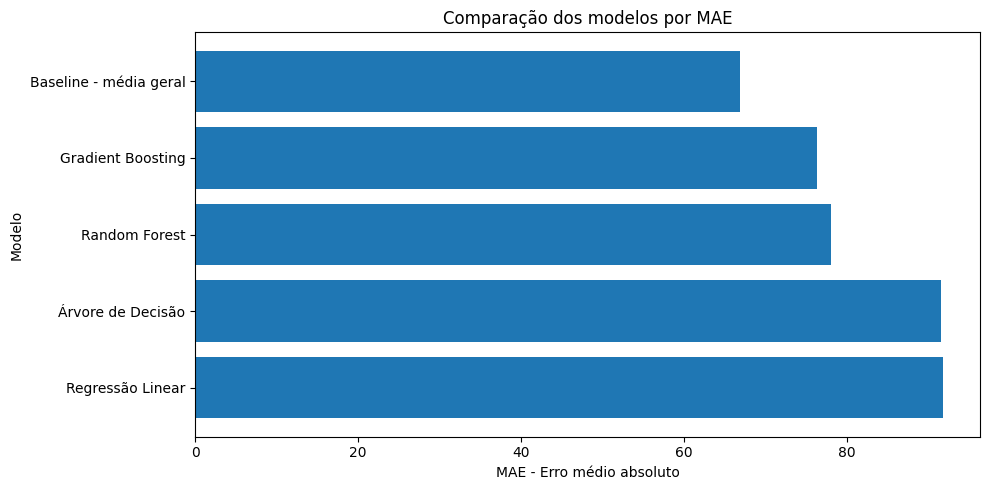

In [48]:
plt.figure(figsize=(10, 5))

plt.barh(df_results_sorted["Modelo"], df_results_sorted["MAE"])

plt.title("Comparação dos modelos por MAE")
plt.xlabel("MAE - Erro médio absoluto")
plt.ylabel("Modelo")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

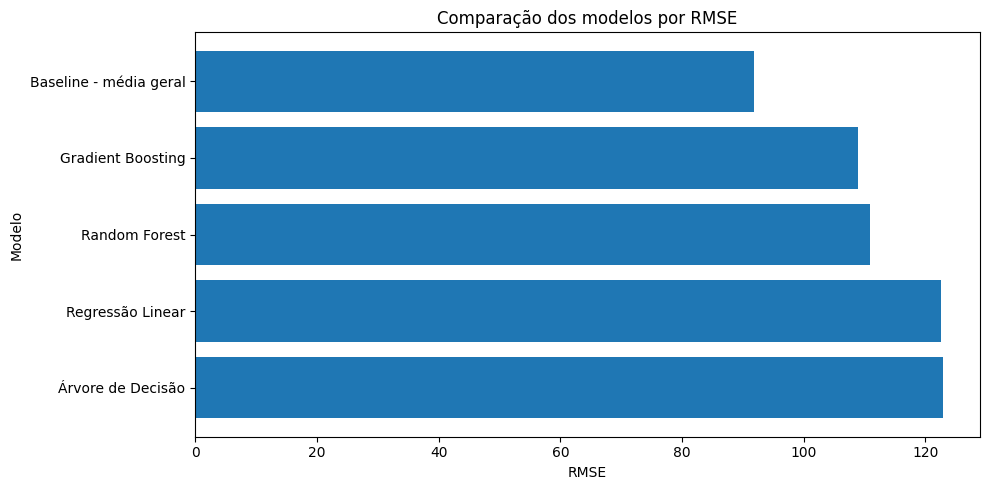

In [49]:
df_results_rmse = df_results.sort_values("RMSE").reset_index(drop=True)

plt.figure(figsize=(10, 5))

plt.barh(df_results_rmse["Modelo"], df_results_rmse["RMSE"])

plt.title("Comparação dos modelos por RMSE")
plt.xlabel("RMSE")
plt.ylabel("Modelo")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [50]:
# Recriando e treinando o melhor modelo de machine learning
best_model = GradientBoostingRegressor(random_state=42)
best_model.fit(X_train, y_train)

y_pred_best = best_model.predict(X_test)

In [51]:
# Comparação entre valores reais e previstos
df_predictions = pd.DataFrame({
    "Valor real": y_test.values,
    "Valor previsto": y_pred_best
})

df_predictions.head()

,Valor real,Valor previsto
0,400.0,107.497346
1,110.0,108.637978
2,30.0,115.789091
3,90.0,121.646018
4,130.0,131.252574


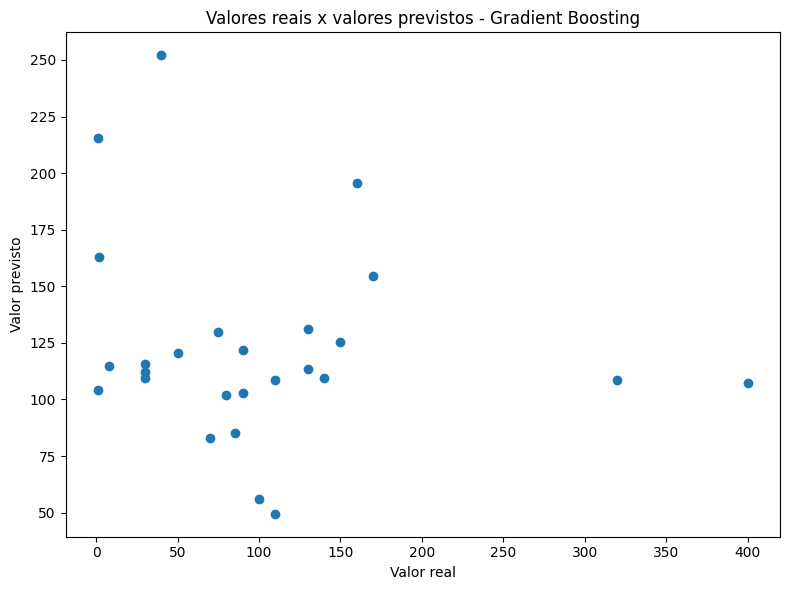

In [52]:
plt.figure(figsize=(8, 6))

plt.scatter(df_predictions["Valor real"], df_predictions["Valor previsto"])

plt.title("Valores reais x valores previstos - Gradient Boosting")
plt.xlabel("Valor real")
plt.ylabel("Valor previsto")
plt.tight_layout()
plt.show()

O gráfico de valores reais e previstos mostra que o modelo apresenta dificuldade em acompanhar alguns preços extremos. Isso reforça a limitação da base atual e indica que a previsão de preços pode ser melhorada com uma coleta mais ampla, maior histórico e padronização das unidades de comercialização.

In [53]:
# Importância das variáveis no modelo Gradient Boosting
feature_importance = pd.DataFrame({
    "feature": X_encoded.columns,
    "importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance", 
    ascending=False
).head(15)

feature_importance

,feature,importance
20,product_name_castanha de caju,0.150651
0,year,0.124580
2,day_of_week,0.109340
1,month,0.078537
3,product_name_abacaxi,0.073922
8,product_name_ameixa seca,0.054880
29,product_name_feijão de corda,0.050930
7,product_name_alho,0.049957
49,product_name_ovos,0.040882
54,product_name_produto subiu,0.035100


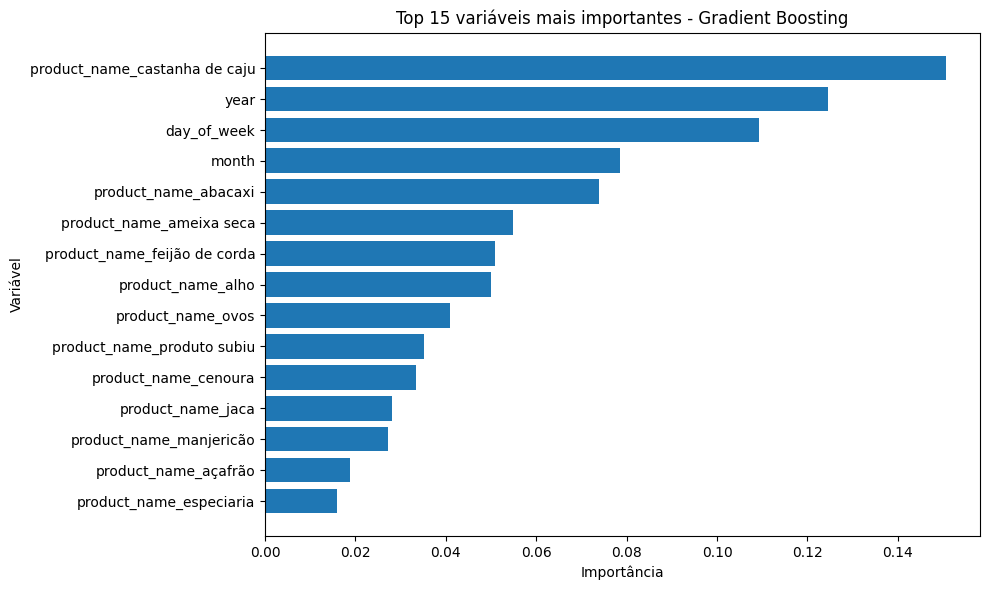

In [54]:
plt.figure(figsize=(10, 6))

plt.barh(feature_importance["feature"], feature_importance["importance"])

plt.title("Top 15 variáveis mais importantes - Gradient Boosting")
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

A análise de importância das variáveis indica quais atributos mais contribuíram para as previsões do modelo Gradient Boosting. Como a base possui poucos registros, essa interpretação deve ser feita com cautela, mas ela ajuda a entender quais produtos, unidades ou variáveis temporais tiveram maior influência no modelo.

## 11. Conclusões

Este projeto teve como objetivo coletar, tratar, analisar e modelar dados públicos de cotações de produtos hortifrutigranjeiros comercializados no Mercado do Produtor de Juazeiro, a partir das publicações da Autarquia Municipal de Abastecimento (AMA).

Ao longo do desenvolvimento, foi possível construir uma base estruturada a partir de dados originalmente não organizados, extraídos de textos de notícias. Após o processo de limpeza e padronização, a base permitiu realizar análises exploratórias relevantes sobre distribuição de preços, produtos com maior frequência de registros, variação de preços e evolução temporal.

Na etapa de modelagem, foram testados diferentes algoritmos de regressão com o objetivo de prever o preço médio dos produtos. Os resultados mostraram que o baseline baseado na média geral do conjunto de treino apresentou melhor desempenho do que os modelos de machine learning testados. Entre os modelos de ML, o Gradient Boosting obteve o melhor resultado, embora ainda com desempenho limitado.

Esses resultados indicam que a base atual possui restrições importantes, como baixo volume de dados, poucos registros por produto, diversidade de unidades de comercialização e extração a partir de textos não padronizados. Ainda assim, o projeto demonstra que dados públicos podem ser organizados e utilizados como ponto de partida para a construção de soluções analíticas e preditivas.

Como trabalhos futuros, recomenda-se ampliar a base histórica, coletar dados de forma mais padronizada, incluir novas variáveis explicativas e consolidar melhor as unidades de comercialização. Com essas melhorias, será possível evoluir para modelos preditivos mais robustos e recomendações de preços mais confiáveis.